# Day 2 — Instruction Tuning & Chat Templates

Learn how instruction-tuned models format conversations using chat templates, and why proper formatting is critical for fine-tuning.

**Sections:**
1. Base Model vs Instruction-Tuned Model — see the difference in behavior
2. Inspecting the Chat Template — what's inside Qwen2.5's Jinja2 template
3. Raw Text vs Template — why role markers matter
4. Building a Dataset — preparing instruction-response pairs
5. Loss Masking — token-level view of what the model learns from

In [1]:
from transformers import AutoTokenizer, pipeline
import torch
import matplotlib.pyplot as plt

c:\Users\Nemochan\Desktop\ai-engineering-journey\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. Base Model vs Instruction-Tuned Model

A base model (GPT-2) was trained only to predict the next token. It does not understand questions. An instruction-tuned model (Qwen2.5) was fine-tuned on conversations and knows how to answer.

In [2]:
question = "Explain what is a firewall in simple words."

# Base model - GPT-2
print("[Base model — GPT-2]")
base = pipeline("text-generation", model="gpt2")
out = base(question, max_new_tokens=60, do_sample=True, temperature=0.7)[0]["generated_text"]
print(f"  Prompt: {question}")
print(f"  Output: {out}\n")

# Instruction-tuned model - Qwen2.5
print("[Instruction-tuned — Qwen2.5-0.5B-Instruct]")
chat = pipeline("text-generation", model="Qwen/Qwen2.5-0.5B-Instruct")
msg = [{"role": "user", "content": question}]
out = chat(msg, max_new_tokens=80)[0]["generated_text"][-1]["content"]
print(f"  Prompt: {question}")
print(f"  Output: {out}\n")

print("GPT-2 may continue the text arbitrarily or ask a question back.")
print("Qwen2.5 answers directly because it was trained on instruction data.")

[Base model — GPT-2]


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 6779.27it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrup

  Prompt: Explain what is a firewall in simple words.
  Output: Explain what is a firewall in simple words.

The basic idea of firewall is that each firewall has some kind of firewall that can handle packets coming from the other side of the firewall. The firewall is a way to identify where packets coming from and get the correct information about them. For example, when a message is sent from the other side

[Instruction-tuned — Qwen2.5-0.5B-Instruct]


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 5576.20it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force clea

  Prompt: Explain what is a firewall in simple words.
  Output: A firewall is a security system that monitors and controls the incoming and outgoing traffic on a network or computer system. It acts as an external barrier between internal networks and the internet, preventing unauthorized access to sensitive information.

Firewalls typically consist of several layers, each with its own set of rules and functions:

1. **Network Interface**: This layer handles the physical connections between devices and ensures they can communicate with

GPT-2 may continue the text arbitrarily or ask a question back.
Qwen2.5 answers directly because it was trained on instruction data.


---
## 2. Inspecting the Chat Template

Every instruction-tuned model has a Jinja2 template that defines how structured messages are converted into a single text string.

In [3]:
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct")

print("Qwen2.5 Chat Template (Jinja2 format):")
print("=" * 60)
print(tokenizer.chat_template)
print("=" * 60)

Qwen2.5 Chat Template (Jinja2 format):
{%- if tools %}
    {{- '<|im_start|>system\n' }}
    {%- if messages[0]['role'] == 'system' %}
        {{- messages[0]['content'] }}
    {%- else %}
        {{- 'You are Qwen, created by Alibaba Cloud. You are a helpful assistant.' }}
    {%- endif %}
    {{- "\n\n# Tools\n\nYou may call one or more functions to assist with the user query.\n\nYou are provided with function signatures within <tools></tools> XML tags:\n<tools>" }}
    {%- for tool in tools %}
        {{- "\n" }}
        {{- tool | tojson }}
    {%- endfor %}
    {{- "\n</tools>\n\nFor each function call, return a json object with function name and arguments within <tool_call></tool_call> XML tags:\n<tool_call>\n{\"name\": <function-name>, \"arguments\": <args-json-object>}\n</tool_call><|im_end|>\n" }}
{%- else %}
    {%- if messages[0]['role'] == 'system' %}
        {{- '<|im_start|>system\n' + messages[0]['content'] + '<|im_end|>\n' }}
    {%- else %}
        {{- '<|im_start|>sys

In [4]:
# Format a conversation to see the special tokens in action
messages = [
    {"role": "system", "content": "You are a cybersecurity expert."},
    {"role": "user", "content": "What is a firewall?"},
    {"role": "assistant", "content": "A firewall monitors traffic and blocks unauthorized access."},
]

formatted = tokenizer.apply_chat_template(messages, tokenize=False)
print("[Formatted conversation]")
print(formatted)

print("\n[Token IDs decoded]")
encoded = tokenizer(formatted, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(encoded.input_ids[0])
print(tokens)

[Formatted conversation]
<|im_start|>system
You are a cybersecurity expert.<|im_end|>
<|im_start|>user
What is a firewall?<|im_end|>
<|im_start|>assistant
A firewall monitors traffic and blocks unauthorized access.<|im_end|>


[Token IDs decoded]
['<|im_start|>', 'system', 'Ċ', 'You', 'Ġare', 'Ġa', 'Ġcybersecurity', 'Ġexpert', '.', '<|im_end|>', 'Ċ', '<|im_start|>', 'user', 'Ċ', 'What', 'Ġis', 'Ġa', 'Ġfirewall', '?', '<|im_end|>', 'Ċ', '<|im_start|>', 'assistant', 'Ċ', 'A', 'Ġfirewall', 'Ġmonitors', 'Ġtraffic', 'Ġand', 'Ġblocks', 'Ġunauthorized', 'Ġaccess', '.', '<|im_end|>', 'Ċ']


---
## 3. Raw Text vs Template — Why Markers Matter

Without role markers, the model cannot distinguish between user questions and assistant responses.

In [5]:
messages = [
    {"role": "system", "content": "You are a cybersecurity expert."},
    {"role": "user", "content": "What is a firewall?"},
    {"role": "assistant", "content": "A firewall monitors and controls incoming and outgoing network traffic based on security rules."},
]

raw_text = "System: You are a cybersecurity expert.\nUser: What is a firewall?\nAssistant: A firewall monitors and controls incoming and outgoing network traffic based on security rules."
template_text = tokenizer.apply_chat_template(messages, tokenize=False)

raw_ids = tokenizer.encode(raw_text)
tmpl_ids = tokenizer.encode(template_text)

print(f"Raw text:             {len(raw_ids):3d} tokens  →  {raw_ids}")
print(f"Template-formatted:   {len(tmpl_ids):3d} tokens  →  {tmpl_ids}")
print(f"\nDifference: {len(tmpl_ids) - len(raw_ids)} extra tokens (role markers)\n")

print("Extra tokens added by template:")
for i, tid in enumerate(tmpl_ids):
    if tid not in raw_ids:
        print(f"  Position {i}: ID {tid} = {tokenizer.decode(tid)!r}")

Raw text:              32 tokens  →  [2320, 25, 1446, 525, 264, 61442, 6203, 624, 1474, 25, 3555, 374, 264, 49877, 5267, 71703, 25, 362, 49877, 36477, 323, 11574, 19393, 323, 36698, 3922, 9442, 3118, 389, 4763, 5601, 13]
Template-formatted:    41 tokens  →  [151644, 8948, 198, 2610, 525, 264, 61442, 6203, 13, 151645, 198, 151644, 872, 198, 3838, 374, 264, 49877, 30, 151645, 198, 151644, 77091, 198, 32, 49877, 36477, 323, 11574, 19393, 323, 36698, 3922, 9442, 3118, 389, 4763, 5601, 13, 151645, 198]

Difference: 9 extra tokens (role markers)

Extra tokens added by template:
  Position 0: ID 151644 = '<|im_start|>'
  Position 1: ID 8948 = 'system'
  Position 2: ID 198 = '\n'
  Position 3: ID 2610 = 'You'
  Position 9: ID 151645 = '<|im_end|>'
  Position 10: ID 198 = '\n'
  Position 11: ID 151644 = '<|im_start|>'
  Position 12: ID 872 = 'user'
  Position 13: ID 198 = '\n'
  Position 14: ID 3838 = 'What'
  Position 18: ID 30 = '?'
  Position 19: ID 151645 = '<|im_end|>'
  Position 20: ID 19

---
## 4. Building a Dataset

A fine-tuning dataset consists of instruction-response pairs formatted with the chat template.

In [6]:
dataset = [
    {"instruction": "What is a firewall?",
     "response": "A firewall monitors and controls incoming and outgoing network traffic based on security rules."},
    {"instruction": "Explain DNS.",
     "response": "DNS, or Domain Name System, translates human-readable domain names into IP addresses."},
    {"instruction": "What is encryption?",
     "response": "Encryption converts plaintext data into ciphertext using an algorithm and a key."},
    {"instruction": "Define phishing.",
     "response": "Phishing is a cyber attack where attackers impersonate legitimate entities to steal information."},
    {"instruction": "What is two-factor authentication?",
     "response": "2FA adds an extra security layer by requiring two verification methods before granting access."},
]

print(f"Dataset: {len(dataset)} instruction-response pairs\n")

token_counts = []
for i, item in enumerate(dataset, 1):
    msg = [
        {"role": "system", "content": "You are a cybersecurity expert."},
        {"role": "user", "content": item["instruction"]},
        {"role": "assistant", "content": item["response"]}
    ]
    formatted = tokenizer.apply_chat_template(msg, tokenize=False)
    tokens = tokenizer.encode(formatted)
    token_counts.append(len(tokens))
    print(f"  Ex {i}: {len(tokens):3d} tokens — {item['instruction']}")

Dataset: 5 instruction-response pairs

  Ex 1:  41 tokens — What is a firewall?
  Ex 2:  41 tokens — Explain DNS.
  Ex 3:  38 tokens — What is encryption?
  Ex 4:  40 tokens — Define phishing.
  Ex 5:  43 tokens — What is two-factor authentication?


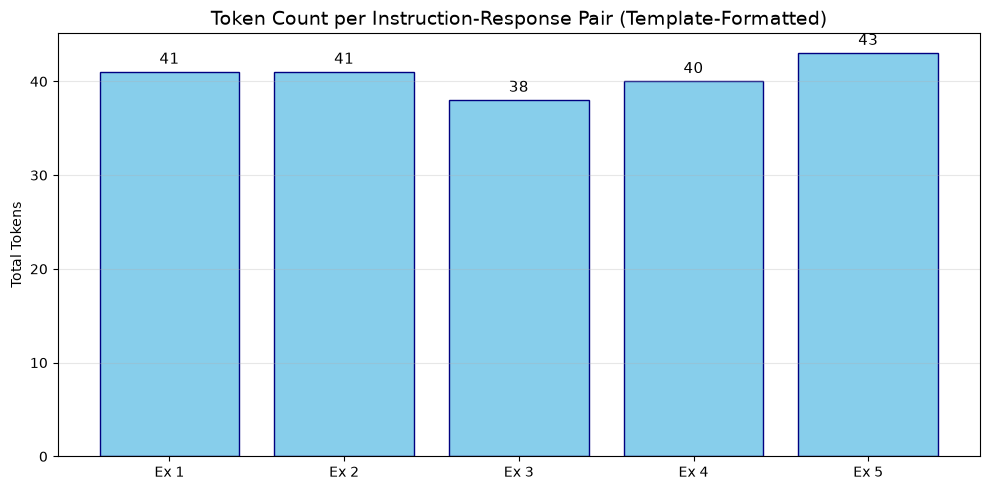

In [7]:
plt.figure(figsize=(10, 5))
bars = plt.bar([f"Ex {i+1}" for i in range(len(dataset))], token_counts, color='skyblue', edgecolor='navy')
plt.title("Token Count per Instruction-Response Pair (Template-Formatted)", fontsize=14)
plt.ylabel("Total Tokens")
plt.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, token_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(count), ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

---
## 5. Loss Masking — Token-Level View

During fine-tuning, we only want the model to learn from the assistant's response. Tokens before that are set to -100 (ignored in loss computation). This cell builds a label array and prints every position so you can see exactly which tokens are learned vs ignored.

In [8]:
item = dataset[0]
msg = [
    {"role": "system", "content": "You are a cybersecurity expert."},
    {"role": "user", "content": item["instruction"]},
    {"role": "assistant", "content": item["response"]}
]

template_text = tokenizer.apply_chat_template(msg, tokenize=False)
encoded = tokenizer(template_text, return_tensors="pt")

# Find where the assistant response starts
assistant_marker = "<|im_start|>assistant"
marker_ids = tokenizer.encode(assistant_marker, add_special_tokens=False)
input_ids = encoded.input_ids[0]

response_start = None
for i in range(len(input_ids) - len(marker_ids) + 1):
    if input_ids[i:i+len(marker_ids)].tolist() == marker_ids:
        response_start = i + len(marker_ids)
        break

if response_start is None:
    print("Could not locate assistant marker.")
else:
    # Build labels: -100 before response, actual IDs after
    labels = torch.full_like(input_ids, -100)
    labels[response_start:] = input_ids[response_start:]

    tokens = tokenizer.convert_ids_to_tokens(input_ids)
    print(f"Total tokens: {len(input_ids)}")
    print(f"Assistant response starts at position {response_start}: "
          f"{tokenizer.decode(input_ids[response_start:response_start+10])!r}...\n")

    print(f"{'Pos':>4} | {'Label':>6} | Token")
    print("-" * 45)
    for pos in range(len(input_ids)):
        label_str = "LEARN" if labels[pos].item() != -100 else "IGNORE"
        token_repr = tokens[pos].replace("\u0120", " ").replace("<0x0A>", "\\n")
        print(f"{pos:4d} | {label_str:>6} | {token_repr}")

    learned = (labels != -100).sum().item()
    ignored = (labels == -100).sum().item()
    print(f"\n→ {learned} tokens learned (assistant response)")
    print(f"→ {ignored} tokens ignored (system prompt + user message)")

Total tokens: 41
Assistant response starts at position 23: '\nA firewall monitors and controls incoming and outgoing network'...

 Pos |  Label | Token
---------------------------------------------
   0 | IGNORE | <|im_start|>
   1 | IGNORE | system
   2 | IGNORE | Ċ
   3 | IGNORE | You
   4 | IGNORE |  are
   5 | IGNORE |  a
   6 | IGNORE |  cybersecurity
   7 | IGNORE |  expert
   8 | IGNORE | .
   9 | IGNORE | <|im_end|>
  10 | IGNORE | Ċ
  11 | IGNORE | <|im_start|>
  12 | IGNORE | user
  13 | IGNORE | Ċ
  14 | IGNORE | What
  15 | IGNORE |  is
  16 | IGNORE |  a
  17 | IGNORE |  firewall
  18 | IGNORE | ?
  19 | IGNORE | <|im_end|>
  20 | IGNORE | Ċ
  21 | IGNORE | <|im_start|>
  22 | IGNORE | assistant
  23 |  LEARN | Ċ
  24 |  LEARN | A
  25 |  LEARN |  firewall
  26 |  LEARN |  monitors
  27 |  LEARN |  and
  28 |  LEARN |  controls
  29 |  LEARN |  incoming
  30 |  LEARN |  and
  31 |  LEARN |  outgoing
  32 |  LEARN |  network
  33 |  LEARN |  traffic
  34 |  LEARN |  based
 

## Key Takeaways

- Base models (GPT-2) cannot answer questions because they weren't trained to — they only predict next tokens
- Instruction-tuned models (Qwen2.5) use chat templates with special tokens to mark who's speaking
- `apply_chat_template()` converts structured messages into formatted text automatically
- Role markers add ~20 extra tokens per conversation but are essential for the model to understand structure
- **Loss masking** sets labels to -100 for system and user tokens so the model only learns from assistant responses